# From Forests to Fossil Fuels: How Ghana's CO₂ Emissions Have Changed (1990–2024)

**Author:** Fiona Neena Achiamaa Frimpong · [GitHub](https://github.com/Fiona-neena) · [LinkedIn](https://linkedin.com/in/fiona-frimpong)
**Tools:** Python (pandas, NumPy, Matplotlib) · **Data:** Our World in Data (Global Carbon Budget 2025, Energy Institute, Ember, Maddison Project)

---

## Summary

For most of the last three decades, Ghana's carbon dioxide emissions came mainly from its forests, through deforestation and other land-use change, rather than from burning fossil fuels. This analysis shows that the balance has flipped.

**Key findings**

1. **Fossil CO₂ emissions grew about six-fold**, from 3.5 Mt in 1990 to 21.0 Mt in 2024 (about 5.4% a year). Oil accounts for 60% of the 2024 total and gas for 37%, and gas emissions barely existed before 2009.
2. **The rise in gas emissions tracks the power sector.** Hydropower supplied 91% of Ghana's electricity in 2000 but only 35% in 2024, while gas-fired generation grew from zero to 61%. Solar is still under 1%.
3. **Land-use change is now the smaller source.** It made up 89% of Ghana's CO₂ emissions (including land use) in 1990 and 39% in 2024, and **2020 was the first year fossil emissions exceeded land-use emissions**.
4. **Ghana's emissions are still low by global standards**: 0.61 tonnes of fossil CO₂ per person in 2024, about 13% of the world average and in the middle of its West African neighbours.
5. **Economic growth has not yet decoupled from emissions.** Between 2000 and 2022, GDP grew 3.5× and fossil CO₂ grew 3.9×. The carbon intensity of the economy has barely changed in two decades.

## Questions this notebook answers

1. How fast have Ghana's fossil CO₂ emissions grown, and which fuels are driving the growth?
2. What explains the rapid rise in emissions from gas?
3. How has the balance between land-use change (forests) and fossil fuels shifted?
4. How does Ghana compare with its West African neighbours and the world?
5. Is Ghana's economy growing faster than its emissions?

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

SOURCES = {
    "co2": "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv",
    "energy": "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv",
}

COUNTRY = "Ghana"
PEERS = ["Ghana", "Nigeria", "Cote d'Ivoire", "Senegal", "Togo", "Burkina Faso"]
BENCHMARKS = ["Africa", "World"]
START, END = 1990, 2024

# Consistent colours across all charts
COLOURS = {
    "oil": "#3B3B3B", "gas": "#E07B39", "flaring": "#C0392B", "other": "#A0A0A0",
    "land_use": "#2E7D4F", "fossil": "#3B3B3B", "hydro": "#2F6DB5", "solar": "#F2B705",
    "gdp": "#2F6DB5", "ghana": "#2E7D4F", "peer": "#9DB8A8", "benchmark": "#7A7A7A",
}
SOURCE_NOTE = "Source: Our World in Data (Global Carbon Budget 2025; Energy Institute; Ember; Maddison Project)."

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10,
})


def save(fig, name):
    # Add the source note and save the figure for the README.
    fig.text(0.01, -0.02, SOURCE_NOTE, fontsize=8, color="#666666")
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=150)

## 2. Load the data

Both datasets come from [Our World in Data](https://ourworldindata.org/), which compiles and documents emissions and energy statistics from primary sources. The function below downloads each file once and reuses the local copy after that, so the notebook runs quickly and still works offline.

In [2]:
def load_owid(name: str) -> pd.DataFrame:
    # Load an Our World in Data dataset, downloading it on first use.
    path = DATA_DIR / f"owid-{name}-data.csv"
    if not path.exists():
        print(f"Downloading {name} data...")
        pd.read_csv(SOURCES[name]).to_csv(path, index=False)
    return pd.read_csv(path)


co2_raw = load_owid("co2")
energy_raw = load_owid("energy")

print(f"CO2 dataset:    {co2_raw.shape[0]:,} rows x {co2_raw.shape[1]} columns, "
      f"{co2_raw['year'].min()}-{co2_raw['year'].max()}")
print(f"Energy dataset: {energy_raw.shape[0]:,} rows x {energy_raw.shape[1]} columns, "
      f"{energy_raw['year'].min()}-{energy_raw['year'].max()}")

CO2 dataset:    50,411 rows x 79 columns, 1750-2024
Energy dataset: 23,377 rows x 130 columns, 1900-2025


## 3. Data quality checks

Before analysing anything, I check three things: which years each variable covers for Ghana, whether the fuel-by-fuel figures add up to the reported total, and how noisy the land-use series is.

In [3]:
ghana = co2_raw[co2_raw["country"] == COUNTRY].set_index("year").sort_index()

key_cols = ["co2", "oil_co2", "gas_co2", "flaring_co2", "cement_co2", "coal_co2",
            "land_use_change_co2", "co2_including_luc", "co2_per_capita", "gdp", "co2_per_gdp"]

coverage = pd.DataFrame({
    "first_year": [ghana[c].first_valid_index() for c in key_cols],
    "last_year": [ghana[c].last_valid_index() for c in key_cols],
    "missing_1990_2024": [ghana.loc[START:END, c].isna().sum() for c in key_cols],
}, index=key_cols)
coverage

,first_year,last_year,missing_1990_2024
co2,1950,2024,0
oil_co2,1950,2024,0
gas_co2,2009,2024,19
flaring_co2,1994,2024,4
cement_co2,1750,2024,0
coal_co2,1950,1997,27
land_use_change_co2,1850,2024,0
co2_including_luc,1950,2024,0
co2_per_capita,1950,2024,0
gdp,1950,2022,2


**What the coverage table shows:**
- Emissions data runs to 2024, but **GDP stops in 2022**, so the economic comparison in Section 8 ends in 2022.
- Gas emissions only begin in 2009 and coal emissions end in 1997. Missing values in these columns mean "no emissions from this fuel", so I treat them as zero when adding fuels together.

In [4]:
fuel_cols = ["oil_co2", "gas_co2", "flaring_co2", "cement_co2", "coal_co2", "other_industry_co2"]
fuel_sum = ghana.loc[START:END, fuel_cols].fillna(0).sum(axis=1)
max_gap = (fuel_sum - ghana.loc[START:END, "co2"]).abs().max()
print(f"Largest gap between the sum of fuels and reported total CO2 (1990-2024): {max_gap:.3f} Mt")

luc = ghana.loc[START:END, "land_use_change_co2"]
print(f"Land-use CO2: min {luc.min():.1f} Mt, max {luc.max():.1f} Mt ({luc.idxmax()}), "
      f"coefficient of variation {luc.std() / luc.mean():.0%}")

Largest gap between the sum of fuels and reported total CO2 (1990-2024): 0.001 Mt
Land-use CO2: min 11.9 Mt, max 67.4 Mt (1996), coefficient of variation 49%


**Result:** the fuel figures add up to the total (the gap is only rounding), so the fuel breakdown can be used with confidence.

The land-use series is much noisier. It swings between about 12 and 67 Mt, with a spike in 1996. National land-use estimates are modelled and far less certain than fossil fuel statistics, so in Section 6 I also use a **5-year rolling average** to show the underlying trend.

## 4. How fast have fossil CO₂ emissions grown, and from which fuels?

In [5]:
g = ghana.loc[START:END].copy()
g["other_co2"] = g[["cement_co2", "coal_co2", "other_industry_co2"]].fillna(0).sum(axis=1)
fuels = g[["oil_co2", "gas_co2", "flaring_co2", "other_co2"]].fillna(0)

years = END - START
cagr = (g.loc[END, "co2"] / g.loc[START, "co2"]) ** (1 / years) - 1
print(f"Fossil CO2: {g.loc[START, 'co2']:.1f} Mt ({START}) -> {g.loc[END, 'co2']:.1f} Mt ({END}), "
      f"{g.loc[END, 'co2'] / g.loc[START, 'co2']:.1f}x, {cagr:.1%} a year")
print(f"Per person: {g.loc[START, 'co2_per_capita']:.2f} t -> {g.loc[END, 'co2_per_capita']:.2f} t")

share_latest = (fuels.loc[END] / fuels.loc[END].sum()).rename("share_of_2024_total")
share_latest.to_frame().style.format("{:.1%}")

Fossil CO2: 3.5 Mt (1990) -> 21.0 Mt (2024), 6.0x, 5.4% a year
Per person: 0.23 t -> 0.61 t


,share_of_2024_total
oil_co2,59.7%
gas_co2,36.5%
flaring_co2,3.6%
other_co2,0.2%


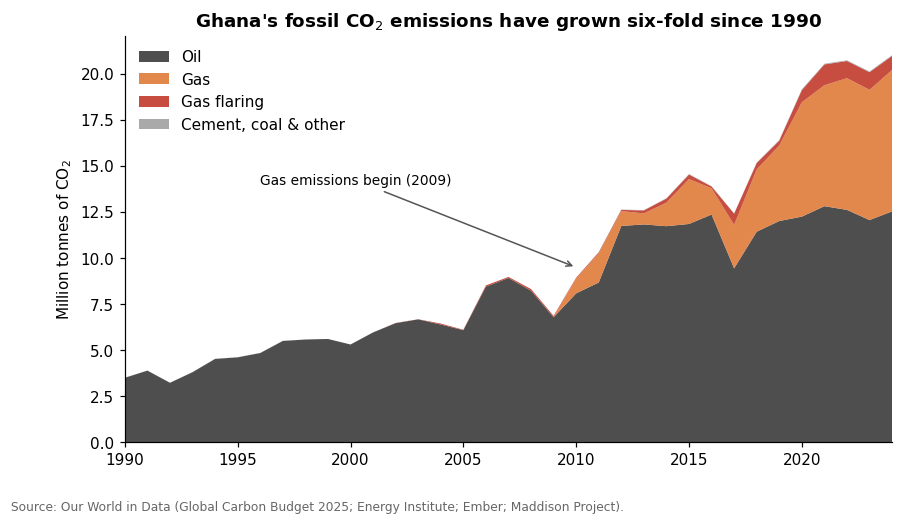

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.8))
labels = {"oil_co2": "Oil", "gas_co2": "Gas", "flaring_co2": "Gas flaring", "other_co2": "Cement, coal & other"}
ax.stackplot(fuels.index, *[fuels[c] for c in labels],
             labels=labels.values(),
             colors=[COLOURS["oil"], COLOURS["gas"], COLOURS["flaring"], COLOURS["other"]], alpha=0.9)
ax.set_title("Ghana's fossil CO$_2$ emissions have grown six-fold since 1990")
ax.set_ylabel("Million tonnes of CO$_2$")
ax.set_xlim(START, END)
ax.legend(loc="upper left", frameon=False)
ax.annotate("Gas emissions begin (2009)", xy=(2010, 9.5), xytext=(1996, 14),
            arrowprops=dict(arrowstyle="->", color="#555555"), fontsize=9)
save(fig, "01_fossil_co2_by_fuel")
plt.show()

**Interpretation:** Oil has been the largest source throughout, and it grew about 3.6× over the period. The biggest structural change is **gas**: it was absent before 2009, and by 2024 it made up **37%** of fossil CO₂. Flaring (burning off gas at oil fields) is small but has grown since oil production expanded in the 2010s.

## 5. What explains the rise in gas emissions?

A likely explanation is electricity generation. The energy dataset lets me test that directly.

In [7]:
elec = (energy_raw[energy_raw["country"] == COUNTRY].set_index("year").sort_index()
        .loc[2000:END, ["hydro_electricity", "gas_electricity", "oil_electricity", "solar_electricity",
                        "electricity_generation"]])
elec_share = elec.drop(columns="electricity_generation").div(elec["electricity_generation"], axis=0)

summary = pd.DataFrame({
    "generation_TWh": elec["electricity_generation"],
    "hydro_share": elec_share["hydro_electricity"],
    "gas_share": elec_share["gas_electricity"],
    "solar_share": elec_share["solar_electricity"],
}).loc[[2000, 2010, 2015, 2020, END]]
summary.style.format({"generation_TWh": "{:.1f}", "hydro_share": "{:.0%}", "gas_share": "{:.0%}", "solar_share": "{:.1%}"})

,generation_TWh,hydro_share,gas_share,solar_share
year,,,,
2000,7.2,91%,0%,0.0%
2010,10.1,68%,13%,0.0%
2015,11.6,50%,42%,0.0%
2020,19.7,37%,59%,0.3%
2024,24.3,35%,61%,0.7%


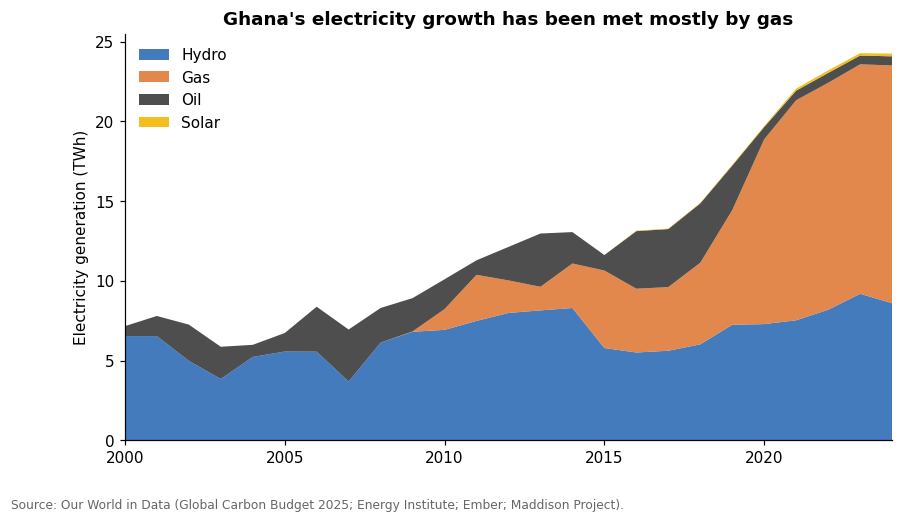

Correlation between gas-fired generation and gas CO2 emissions (2009-2024): 0.99


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.8))
src = {"hydro_electricity": ("Hydro", COLOURS["hydro"]), "gas_electricity": ("Gas", COLOURS["gas"]),
       "oil_electricity": ("Oil", COLOURS["oil"]), "solar_electricity": ("Solar", COLOURS["solar"])}
ax.stackplot(elec.index, *[elec[c] for c in src], labels=[v[0] for v in src.values()],
             colors=[v[1] for v in src.values()], alpha=0.9)
ax.set_title("Ghana's electricity growth has been met mostly by gas")
ax.set_ylabel("Electricity generation (TWh)")
ax.set_xlim(2000, END)
ax.legend(loc="upper left", frameon=False)
save(fig, "02_electricity_mix")
plt.show()

print(f"Correlation between gas-fired generation and gas CO2 emissions (2009-{END}): "
      f"{elec.loc[2009:END, 'gas_electricity'].corr(ghana.loc[2009:END, 'gas_co2']):.2f}")

**Interpretation:** Electricity generation more than tripled between 2000 and 2024. Hydropower output grew only modestly, so most of the growth came from **gas-fired plants**. Hydro's share fell from 91% to 35%, and gas rose from zero to 61%. Gas-fired generation and gas CO₂ emissions move almost in step, which supports the power sector explanation. A correlation doesn't prove cause, but the timing and scale match. Solar is still under 1% of generation.

## 6. Forests vs fossil fuels: how has the balance shifted?

In [9]:
balance = pd.DataFrame({
    "fossil_co2": g["co2"],
    "land_use_co2": g["land_use_change_co2"],
    "land_use_5yr_avg": g["land_use_change_co2"].rolling(5).mean(),
})
balance["land_use_share"] = balance["land_use_co2"] / (balance["fossil_co2"] + balance["land_use_co2"])

crossover = balance.index[balance["fossil_co2"] > balance["land_use_co2"]].min()
print(f"First year fossil CO2 exceeded land-use CO2: {crossover}")
print(f"Average land-use share: 1990s {balance.loc[1990:1999, 'land_use_share'].mean():.0%}, "
      f"2015-2024 {balance.loc[2015:2024, 'land_use_share'].mean():.0%}")
balance.loc[[1990, 2000, 2010, 2020, END]]

First year fossil CO2 exceeded land-use CO2: 2020
Average land-use share: 1990s 88%, 2015-2024 48%


,fossil_co2,land_use_co2,land_use_5yr_avg,land_use_share
year,,,,
1990,3.51,28.81,NaN,0.89
2000,5.31,27.41,40.49,0.84
2010,8.94,19.56,17.73,0.69
2020,19.16,16.10,18.25,0.46
2024,21.02,13.53,13.35,0.39


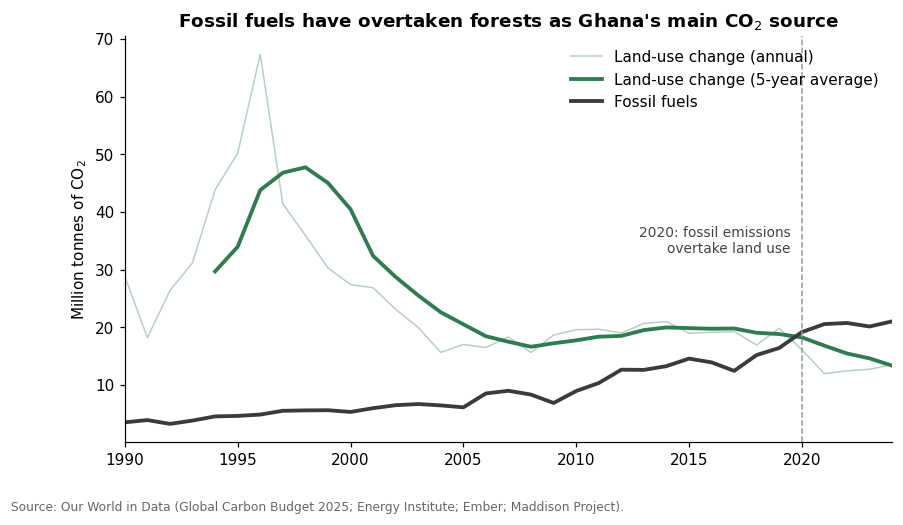

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(balance.index, balance["land_use_co2"], color=COLOURS["land_use"], alpha=0.35, lw=1, label="Land-use change (annual)")
ax.plot(balance.index, balance["land_use_5yr_avg"], color=COLOURS["land_use"], lw=2.5, label="Land-use change (5-year average)")
ax.plot(balance.index, balance["fossil_co2"], color=COLOURS["fossil"], lw=2.5, label="Fossil fuels")
ax.axvline(crossover, color="#999999", ls="--", lw=1)
ax.text(crossover - 0.5, 33, f"{crossover}: fossil emissions\novertake land use", ha="right", fontsize=9, color="#444444")
ax.set_title("Fossil fuels have overtaken forests as Ghana's main CO$_2$ source")
ax.set_ylabel("Million tonnes of CO$_2$")
ax.set_xlim(START, END)
ax.legend(loc="upper right", frameon=False)
save(fig, "03_forests_vs_fossil")
plt.show()

**Interpretation:** In the 1990s, land-use change made up almost **nine-tenths** of Ghana's CO₂ emissions. By 2015–2024 the average share had fallen to under half, and in **2020** fossil emissions overtook land-use emissions for the first time. Two things drove the shift: estimated land-use emissions have fallen since the early 2000s, and fossil emissions have climbed steadily.

**Caution:** national land-use emissions are modelled estimates with wide uncertainty. The direction of the trend is more reliable than any single year's value. Satellite-based forest loss data (for example Global Forest Watch) would be a useful cross-check.

## 7. How does Ghana compare with its neighbours and the world?

In [11]:
latest = (co2_raw[co2_raw["country"].isin(PEERS + BENCHMARKS) & (co2_raw["year"] == END)]
          .set_index("country")[["co2_per_capita", "co2_including_luc_per_capita"]])
latest["land_use_per_capita"] = latest["co2_including_luc_per_capita"] - latest["co2_per_capita"]
latest = latest.sort_values("co2_per_capita")

ghana_vs_world = latest.loc["Ghana", "co2_per_capita"] / latest.loc["World", "co2_per_capita"]
print(f"Ghana's fossil CO2 per person is {ghana_vs_world:.0%} of the world average in {END}.")
latest

Ghana's fossil CO2 per person is 13% of the world average in 2024.


,co2_per_capita,co2_including_luc_per_capita,land_use_per_capita
country,,,
Burkina Faso,0.28,1.48,1.21
Togo,0.33,0.57,0.24
Cote d'Ivoire,0.46,7.90,7.44
Nigeria,0.58,0.77,0.19
Ghana,0.61,1.00,0.39
Senegal,0.76,1.08,0.32
Africa,0.99,2.20,1.21
World,4.73,5.29,0.56


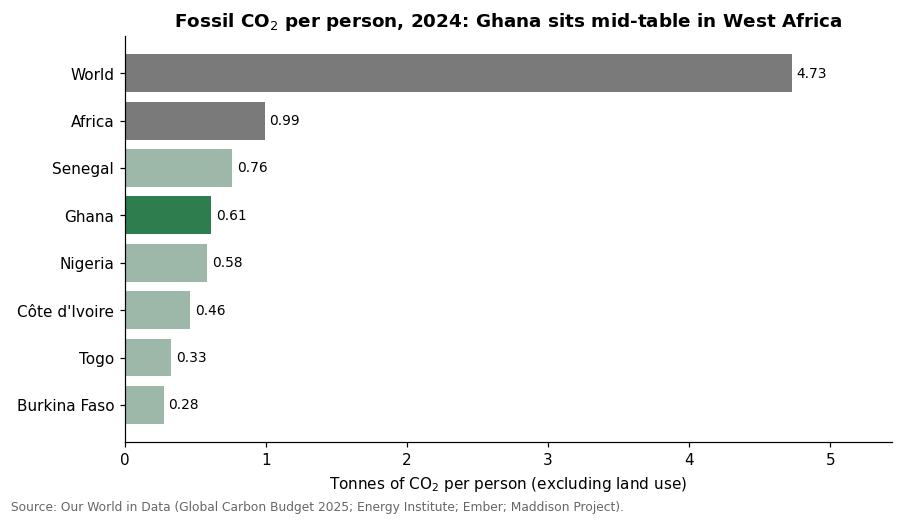

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.8))
colours = [COLOURS["ghana"] if c == "Ghana" else COLOURS["benchmark"] if c in BENCHMARKS else COLOURS["peer"]
           for c in latest.index]
bars = ax.barh(latest.index.str.replace("Cote d'Ivoire", "Côte d'Ivoire"), latest["co2_per_capita"], color=colours)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set_title(f"Fossil CO$_2$ per person, {END}: Ghana sits mid-table in West Africa")
ax.set_xlabel("Tonnes of CO$_2$ per person (excluding land use)")
ax.set_xlim(0, latest["co2_per_capita"].max() * 1.15)
save(fig, "04_per_capita_comparison")
plt.show()

**Interpretation:** Ghana emits about **0.6 tonnes of fossil CO₂ per person**. That's similar to Nigeria, below Senegal and the African average, and about **one-eighth of the world average**.

The land-use column in the table tells a different story for **Côte d'Ivoire**: once land-use change is included, its per-person emissions jump to about 7.9 tonnes, more than the world average. That reflects its estimated forest loss, and it's a reminder that for forest countries, fossil-only figures can hide a large part of the picture.

## 8. Is Ghana's economy growing faster than its emissions?

In [13]:
BASE, GDP_END = 2000, 2022
econ = ghana.loc[BASE:GDP_END, ["gdp", "co2", "population", "co2_per_gdp"]].copy()
index = econ[["gdp", "co2", "population"]].div(econ.loc[BASE, ["gdp", "co2", "population"]]) * 100

growth = (econ.loc[GDP_END, ["gdp", "co2", "population"]] / econ.loc[BASE, ["gdp", "co2", "population"]]).rename("growth_multiple")
print(growth.round(2).to_string())
print(f"\nCarbon intensity (kg CO2 per $ of GDP): {econ.loc[BASE:BASE+4, 'co2_per_gdp'].mean():.3f} (2000-04 avg) "
      f"vs {econ.loc[GDP_END-4:GDP_END, 'co2_per_gdp'].mean():.3f} (2018-22 avg)")

gdp          3.50
co2          3.90
population   1.69

Carbon intensity (kg CO2 per $ of GDP): 0.134 (2000-04 avg) vs 0.135 (2018-22 avg)


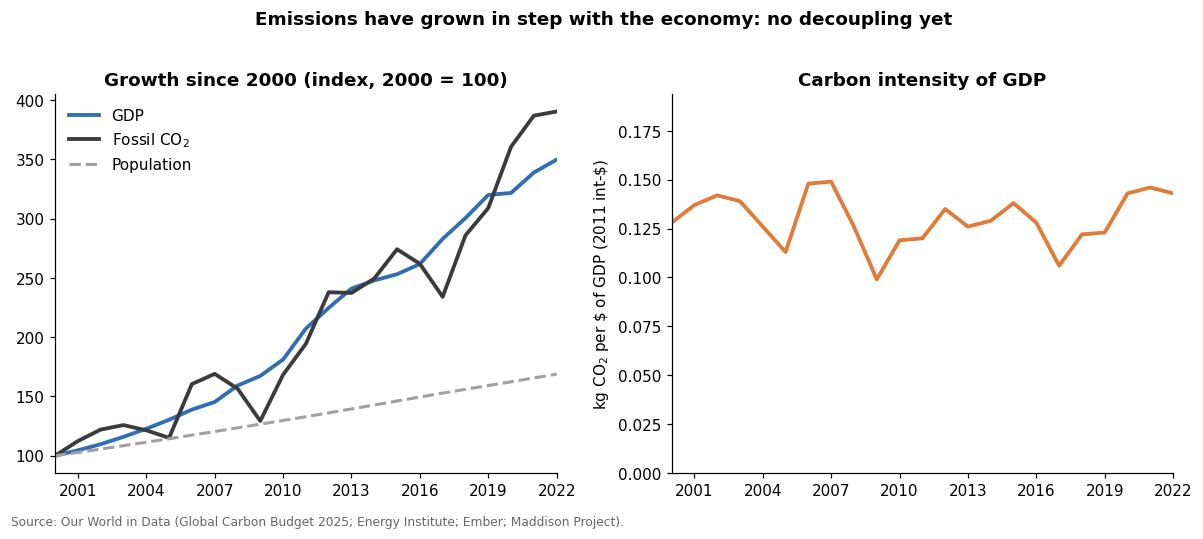

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(index.index, index["gdp"], color=COLOURS["gdp"], lw=2.5, label="GDP")
ax1.plot(index.index, index["co2"], color=COLOURS["fossil"], lw=2.5, label="Fossil CO$_2$")
ax1.plot(index.index, index["population"], color=COLOURS["other"], lw=2, ls="--", label="Population")
ax1.set_title(f"Growth since {BASE} (index, {BASE} = 100)")
ax1.legend(frameon=False)
ax1.set_xlim(BASE, GDP_END)

ax2.plot(econ.index, econ["co2_per_gdp"], color=COLOURS["gas"], lw=2.5)
ax2.set_title("Carbon intensity of GDP")
ax2.set_ylabel(r"kg CO$_2$ per \$ of GDP (2011 int-\$)")
ax2.set_ylim(0, econ["co2_per_gdp"].max() * 1.3)
ax2.set_xlim(BASE, GDP_END)
for a in (ax1, ax2):
    a.xaxis.set_major_locator(mtick.MaxNLocator(integer=True))
fig.suptitle("Emissions have grown in step with the economy: no decoupling yet", fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "05_decoupling")
plt.show()

**Interpretation:** Between 2000 and 2022, Ghana's economy grew about **3.5×** and its fossil CO₂ emissions about **3.9×**, both much faster than population (1.7×). Carbon intensity has moved up and down but is essentially the same as twenty years ago. Each dollar of economic output still produces about the same amount of CO₂, so growth has not yet become cleaner.

This isn't unusual for a lower-middle-income country building out its power supply. It does suggest that the choice of how Ghana meets future electricity demand (more gas, or more solar and other renewables) will largely decide whether emissions keep rising with the economy.

## 9. Conclusions

| Question | Answer |
|---|---|
| How fast have fossil emissions grown? | About 6× since 1990 (5.4% a year), to 21.0 Mt in 2024 |
| What is driving the growth? | Oil (60% of 2024 emissions) and, since 2009, gas (37%), mostly from the shift to gas-fired power |
| Forests vs fossil fuels? | Land use fell from 89% of CO₂ emissions (1990) to 39% (2024); fossil fuels overtook it in 2020 |
| How does Ghana compare? | 0.61 t per person: mid-table in West Africa, about 13% of the world average |
| Is growth decoupling from emissions? | Not yet: carbon intensity is flat over two decades |

**What this means in practice**

- **The power sector is the main lever.** Almost all new electricity demand has been met with gas. Scaling up solar, currently under 1% of generation, is the clearest way to break the link between growth and emissions.
- **Forest emissions still matter.** They're falling, but at about 13 Mt a year they remain a large share of the total. Conservation and restoration programmes should be judged on independent, satellite-based forest data, not modelled estimates alone.
- **Oil is the largest source, but this dataset can't show which sector uses it.** Transport is the likely candidate, but that needs checking with sector-level data.

## 10. Limitations and next steps

- **Land-use estimates are uncertain.** They're modelled (Global Carbon Budget) and vary a lot from year to year. Next step: compare with Global Forest Watch tree cover loss data for Ghana.
- **Sector detail.** Break fossil emissions down by sector (transport, power, industry) using Climate Watch or IEA data to test the transport hypothesis.
- **GDP ends in 2022**, so the decoupling analysis can't yet include 2023–2024.
- **Data updates.** Our World in Data updates these files regularly, so rerunning the notebook later may change the figures slightly. These results use the Global Carbon Budget 2025 release.